
# Heart Disease Classification - PyTorch DNN 실습 노트북

이 노트북은 제공된 `heart.py` 파일의 PyTorch 기반 심장질환 이진 분류 코드를 Google Colab / Jupyter Notebook에서 단계별로 실행할 수 있도록 재구성한 버전입니다.

## 학습 목표

1. `heart.csv` 데이터를 읽고 구조를 확인한다.
2. 입력 데이터와 정답 데이터를 분리한다.
3. 학습용 데이터와 평가용 데이터를 나눈다.
4. 입력 데이터를 Z-점수 정규화한다.
5. PyTorch로 DNN(Deep Neural Network) 모델을 만든다.
6. 손실 함수와 최적화 함수를 사용하여 모델을 학습한다.
7. 예측 확률을 0 또는 1로 변환하여 F1 점수로 평가한다.

> 실행 전 주의: 이 노트북과 같은 폴더에 `heart.csv` 파일이 있어야 합니다.


In [1]:

# ============================================================
# 1. 기본 라이브러리 임포트
# ============================================================

# pandas는 표 형태의 데이터를 다루기 위한 라이브러리입니다.
# CSV 파일을 읽거나, 데이터프레임 형태로 데이터를 확인할 때 사용합니다.
import pandas as pd

# matplotlib.pyplot은 그래프를 그리기 위한 기본 시각화 라이브러리입니다.
import matplotlib.pyplot as plt

# seaborn은 matplotlib보다 더 보기 좋은 통계 그래프를 쉽게 그릴 수 있게 해주는 라이브러리입니다.
import seaborn as sns

# time 함수는 학습 시작 시각과 종료 시각을 측정하여 전체 학습 시간을 계산할 때 사용합니다.
from time import time

# numpy는 수치 계산용 라이브러리입니다.
# 난수 고정이나 배열 계산에 사용합니다.
import numpy as np

# torch는 PyTorch의 핵심 라이브러리입니다.
# 텐서 생성, 자동 미분, GPU 연산 등을 수행할 수 있습니다.
import torch

# torch.nn은 신경망 계층, 활성화 함수, 손실 함수 등을 제공하는 모듈입니다.
from torch import nn

# train_test_split은 데이터를 학습용과 평가용으로 나누는 함수입니다.
from sklearn.model_selection import train_test_split

# StandardScaler는 평균 0, 표준편차 1이 되도록 Z-점수 정규화를 수행합니다.
from sklearn.preprocessing import StandardScaler

# f1_score는 분류 모델의 성능을 평가하는 지표입니다.
# 특히 클래스 불균형이 있을 때 정확도보다 더 유용할 수 있습니다.
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report


In [2]:

# ============================================================
# 2. 하이퍼파라미터 및 실행 옵션 설정
# ============================================================

# 입력 특성 개수입니다.
# heart.csv 데이터는 일반적으로 age, sex, cp 등 13개의 입력 컬럼과 target 컬럼을 가집니다.
INPUT_DIM = 13

# 은닉층 뉴런 개수입니다.
# 값이 클수록 모델 표현력이 커지지만, 학습 시간이 길어지고 과적합 위험도 증가합니다.
MY_HIDDEN = 1000

# 전체 학습 반복 횟수입니다.
# epoch는 전체 학습 데이터를 한 번 모두 사용하여 학습하는 단위입니다.
MY_EPOCH = 1000

# 학습률입니다.
# 가중치를 한 번 업데이트할 때 얼마나 크게 이동할지 결정합니다.
LEARNING_RATE = 0.01

# 결과 재현을 위한 난수 고정값입니다.
# 같은 코드를 실행했을 때 최대한 비슷한 결과가 나오도록 도와줍니다.
SEED = 111

# pandas 출력 옵션입니다.
# 데이터프레임을 출력할 때 모든 컬럼이 보이도록 설정합니다.
pd.set_option('display.max_columns', None)

# PyTorch 난수 시드를 고정합니다.
torch.manual_seed(SEED)

# NumPy 난수 시드를 고정합니다.
np.random.seed(SEED)

# GPU 사용 가능 여부를 확인합니다.
# CUDA가 사용 가능하면 GPU를 사용하고, 아니면 CPU를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)


사용 장치: cuda



## 3. 데이터 준비

이 단계에서는 `heart.csv` 파일을 읽어옵니다.  
파일은 노트북과 같은 폴더에 있어야 하며, Google Colab에서는 왼쪽 파일 영역에 업로드한 뒤 실행하면 됩니다.

일반적인 Heart Disease 데이터셋은 다음과 같은 컬럼을 포함합니다.

- `age`: 나이
- `sex`: 성별
- `cp`: 흉통 유형
- `trestbps`: 안정 혈압
- `chol`: 콜레스테롤 수치
- `fbs`: 공복 혈당
- `restecg`: 안정 심전도 결과
- `thalach`: 최대 심박수
- `exang`: 운동 유발 협심증 여부
- `oldpeak`: ST depression 수치
- `slope`: ST segment 기울기
- `ca`: 주요 혈관 수
- `thal`: thalassemia 관련 값
- `target`: 심장질환 여부 정답값


In [4]:

# ============================================================
# 3. 데이터 파일 읽기
# ============================================================

# heart.csv 파일을 pandas 데이터프레임으로 읽어옵니다.
# 데이터프레임은 엑셀 표와 비슷하게 행과 열로 구성된 데이터 구조입니다.
raw = pd.read_csv('heart.csv')

# 원본 데이터의 앞 10개 행을 출력하여 데이터가 정상적으로 읽혔는지 확인합니다.
print('원본 데이터 샘플 10개')
display(raw.head(10))

# 원본 데이터의 기초 통계량을 확인합니다.
# count: 데이터 개수
# mean: 평균
# std: 표준편차
# min: 최솟값
# 25%, 50%, 75%: 사분위수
# max: 최댓값
print('원본 데이터 통계')
display(raw.describe())

# 데이터프레임의 전체 행/열 개수를 확인합니다.
print("원본 데이터 모양:", raw.shape)


원본 데이터 샘플 10개


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


원본 데이터 통계


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


원본 데이터 모양: (303, 14)


In [5]:

# ============================================================
# 4. 입력 데이터와 정답 데이터 분리
# ============================================================

# target 컬럼은 모델이 맞혀야 하는 정답값입니다.
# 따라서 입력 데이터 X_data에서는 target 컬럼을 제거합니다.
X_data = raw.drop('target', axis=1)

# Y_data에는 정답값인 target 컬럼만 저장합니다.
# 일반적으로 0은 심장질환 없음, 1은 심장질환 있음으로 해석합니다.
Y_data = raw['target']

# 입력 컬럼명을 저장합니다.
# 정규화 후 다시 데이터프레임으로 만들 때 컬럼명을 복원하기 위해 사용합니다.
names = X_data.columns

# 입력 컬럼명을 출력합니다.
print("입력 컬럼명:")
print(names)

# 입력 데이터와 정답 데이터의 모양을 확인합니다.
print("입력 데이터 모양:", X_data.shape)
print("정답 데이터 모양:", Y_data.shape)


입력 컬럼명:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')
입력 데이터 모양: (303, 13)
정답 데이터 모양: (303,)


In [6]:

# ============================================================
# 5. 학습용 데이터와 평가용 데이터 분리
# ============================================================

# train_test_split은 전체 데이터를 학습용과 평가용으로 나누는 함수입니다.
# test_size=0.3은 전체 데이터 중 30%를 평가용 데이터로 사용한다는 뜻입니다.
# random_state를 지정하면 데이터를 나누는 방식이 고정되어 결과 재현성이 좋아집니다.
# stratify=Y_data는 target의 0/1 비율이 학습용과 평가용에 비슷하게 유지되도록 합니다.
X_train, X_test, Y_train, Y_test = train_test_split(
    X_data,
    Y_data,
    test_size=0.3,
    random_state=SEED,
    stratify=Y_data
)

# 최종 데이터 모양을 출력하여 제대로 분리되었는지 확인합니다.
print('\n학습용 입력 데이터 모양:', X_train.shape)
print('학습용 출력 데이터 모양:', Y_train.shape)
print('평가용 입력 데이터 모양:', X_test.shape)
print('평가용 출력 데이터 모양:', Y_test.shape)

# 학습용/평가용 정답 비율을 확인합니다.
print("\n학습용 target 비율")
print(Y_train.value_counts(normalize=True))

print("\n평가용 target 비율")
print(Y_test.value_counts(normalize=True))



학습용 입력 데이터 모양: (212, 13)
학습용 출력 데이터 모양: (212,)
평가용 입력 데이터 모양: (91, 13)
평가용 출력 데이터 모양: (91,)

학습용 target 비율
target
1    0.542453
0    0.457547
Name: proportion, dtype: float64

평가용 target 비율
target
1    0.549451
0    0.450549
Name: proportion, dtype: float64


In [7]:

# ============================================================
# 6. 입력 데이터 Z-점수 정규화
# ============================================================

# StandardScaler는 각 컬럼을 평균 0, 표준편차 1이 되도록 변환합니다.
# 서로 단위가 다른 컬럼들이 있을 때 신경망 학습을 안정적으로 만드는 데 도움이 됩니다.
scaler = StandardScaler()

# fit_transform은 학습 데이터의 평균과 표준편차를 계산한 뒤 정규화까지 수행합니다.
# 주의: scaler는 반드시 학습 데이터에만 fit 해야 합니다.
# 평가 데이터까지 함께 fit하면 평가 데이터 정보가 학습 과정에 새는 데이터 누수 문제가 생깁니다.
X_train_scaled = scaler.fit_transform(X_train)

# transform은 학습 데이터에서 계산한 평균과 표준편차를 평가 데이터에 그대로 적용합니다.
# 평가 데이터에는 fit_transform이 아니라 transform만 사용해야 합니다.
X_test_scaled = scaler.transform(X_test)

# 정규화 결과는 NumPy 배열이므로 다시 pandas 데이터프레임으로 변환합니다.
# 컬럼명을 복구하면 출력과 시각화가 이해하기 쉬워집니다.
X_train_scaled = pd.DataFrame(X_train_scaled, columns=names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=names)

# 정규화된 학습용 데이터 샘플을 출력합니다.
print('\n정규화된 학습용 데이터 샘플 10개')
display(X_train_scaled.head(10))

# 정규화된 학습용 데이터의 통계를 확인합니다.
# 평균이 거의 0, 표준편차가 거의 1에 가까운지 확인합니다.
print('정규화된 학습용 데이터 통계')
display(X_train_scaled.describe())



정규화된 학습용 데이터 샘플 10개


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.099689,-1.409225,1.084217,-1.386511,0.336180,-0.421637,-1.041375,0.796619,-0.709610,-0.910689,1.029994,-0.723105,-0.490357
1,0.013935,-1.409225,-0.880347,2.790261,1.417671,-0.421637,2.765030,-1.475148,1.409225,1.926063,-0.587478,-0.723105,-0.490357
2,0.922928,0.709610,-0.880347,-0.110275,1.471746,2.371708,-1.041375,-0.793618,1.409225,0.591121,1.029994,2.363437,1.084730
3,-1.008682,0.709610,-0.880347,-0.690382,0.011733,-0.421637,-1.041375,-0.248394,-0.709610,-0.243218,1.029994,-0.723105,1.084730
4,0.127559,0.709610,-0.880347,0.005746,-1.159882,-0.421637,-1.041375,-2.020372,1.409225,0.841423,-0.587478,0.305742,-2.065445
5,1.718297,0.709610,1.084217,1.630047,0.372230,-0.421637,0.861827,-1.702325,1.409225,1.508894,-0.587478,0.305742,1.084730
6,-0.440562,0.709610,1.084217,-0.400329,-0.060366,2.371708,-1.041375,0.751183,-0.709610,1.091724,-0.587478,-0.723105,-0.490357
7,-0.440562,-1.409225,1.084217,-0.690382,0.840876,-0.421637,-1.041375,0.342265,-0.709610,-0.410085,1.029994,-0.723105,-0.490357
8,-0.326937,0.709610,0.101935,0.121768,-0.853460,-0.421637,0.861827,0.387701,-0.709610,-0.243218,1.029994,0.305742,-0.490357
9,1.036552,0.709610,-0.880347,-0.226297,0.264081,-0.421637,0.861827,-2.020372,1.409225,-0.743821,-0.587478,0.305742,1.084730


정규화된 학습용 데이터 통계


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02
mean,-8.379042e-17,-1.675808e-17,-3.351617e-17,3.121193e-16,-1.173066e-16,7.331661e-18,4.189521e-17,5.195006e-16,2.094760e-17,-3.351617e-17,6.703233e-17,8.379042e-18,-6.703233e-17
std,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00
min,-2.258548e+00,-1.409225e+00,-8.803469e-01,-2.198661e+00,-2.205323e+00,-4.216370e-01,-1.041375e+00,-3.565174e+00,-7.096098e-01,-9.106886e-01,-2.204951e+00,-7.231050e-01,-3.640533e+00
25%,-7.814340e-01,-1.409225e+00,-8.803469e-01,-6.903823e-01,-6.596925e-01,-4.216370e-01,-1.041375e+00,-6.345945e-01,-7.096098e-01,-9.106886e-01,-5.874782e-01,-7.231050e-01,-4.903575e-01
50%,1.275592e-01,7.096098e-01,-3.892060e-01,-1.102751e-01,-1.685153e-01,-4.216370e-01,8.618275e-01,1.605239e-01,-7.096098e-01,-2.432176e-01,-5.874782e-01,-7.231050e-01,-4.903575e-01
75%,8.093040e-01,7.096098e-01,1.084217e+00,4.698321e-01,5.930345e-01,-4.216370e-01,8.618275e-01,7.057480e-01,1.409225e+00,5.911211e-01,1.029994e+00,3.057424e-01,1.084730e+00
max,2.513666e+00,7.096098e-01,2.066499e+00,3.486390e+00,5.689560e+00,2.371708e+00,2.765030e+00,2.068808e+00,1.409225e+00,4.262211e+00,1.029994e+00,3.392285e+00,1.084730e+00


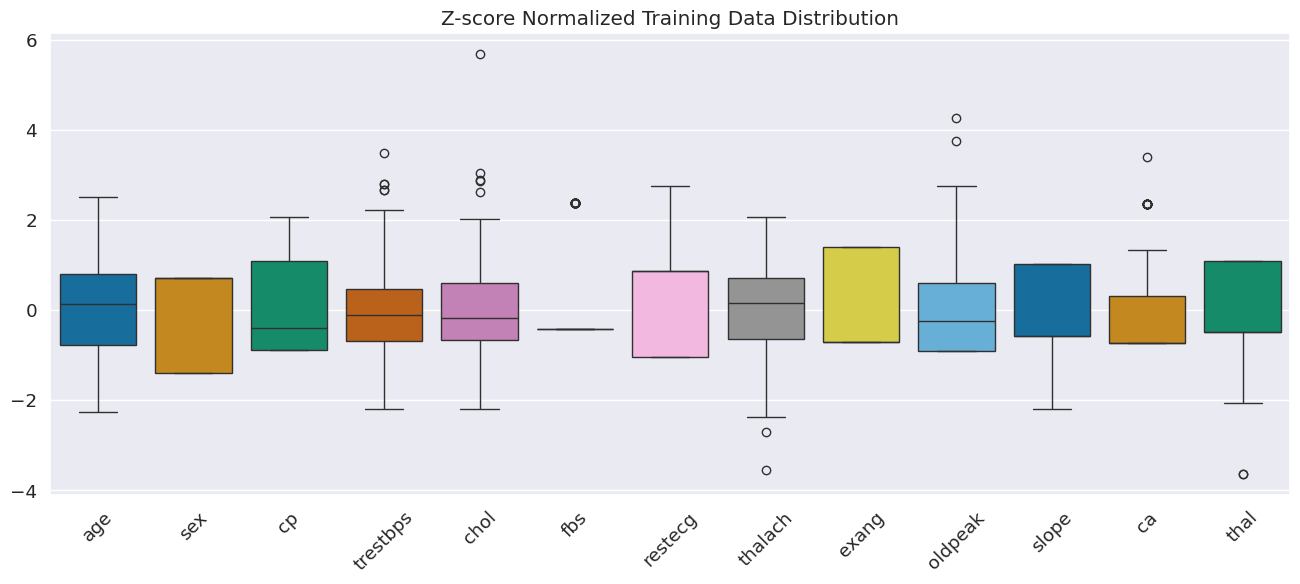

In [8]:

# ============================================================
# 7. 정규화된 데이터 분포 시각화
# ============================================================

# 그래프 글자 크기를 설정합니다.
sns.set(font_scale=1.2)

# 그래프 크기를 지정합니다.
plt.figure(figsize=(16, 6))

# boxplot은 각 컬럼의 분포, 중앙값, 이상치를 확인하는 그래프입니다.
# 정규화 후 대부분의 컬럼이 비슷한 범위에 놓이는지 확인할 수 있습니다.
sns.boxplot(data=X_train_scaled, palette="colorblind")

# x축 글자들이 겹치지 않도록 회전합니다.
plt.xticks(rotation=45)

# 그래프 제목을 지정합니다.
plt.title("Z-score Normalized Training Data Distribution")

# 그래프를 화면에 출력합니다.
plt.show()



## 8. PyTorch DNN 모델 구현

이 모델은 다음 구조를 가집니다.

입력층 13개 → 은닉층 1000개 → Tanh → 은닉층 1000개 → Tanh → 출력층 1개 → Sigmoid

출력층의 Sigmoid는 결과를 0과 1 사이 확률값으로 바꾸기 위해 사용합니다.


In [9]:

# ============================================================
# 8. PyTorch DNN 모델 정의
# ============================================================

# nn.Sequential은 여러 신경망 계층을 순서대로 쌓을 때 사용하는 방식입니다.
# 입력 데이터가 첫 번째 계층부터 마지막 계층까지 순서대로 지나갑니다.
model = nn.Sequential(
    # 첫 번째 완전연결층입니다.
    # 입력 특성 13개를 받아서 MY_HIDDEN개 뉴런으로 변환합니다.
    nn.Linear(INPUT_DIM, MY_HIDDEN),

    # Tanh 활성화 함수입니다.
    # 신경망이 비선형 패턴을 학습할 수 있도록 도와줍니다.
    nn.Tanh(),

    # 두 번째 완전연결층입니다.
    # 은닉층 출력 MY_HIDDEN개를 다시 MY_HIDDEN개로 변환합니다.
    nn.Linear(MY_HIDDEN, MY_HIDDEN),

    # 두 번째 활성화 함수입니다.
    nn.Tanh(),

    # 출력층입니다.
    # 이진 분류이므로 최종 출력 뉴런은 1개입니다.
    nn.Linear(MY_HIDDEN, 1),

    # Sigmoid 함수는 출력값을 0~1 사이 확률로 변환합니다.
    # 0.5보다 크면 1, 작거나 같으면 0으로 분류할 수 있습니다.
    nn.Sigmoid()
)

# 모델을 CPU 또는 GPU 장치로 이동합니다.
model = model.to(device)

# 모델 구조를 출력합니다.
print('\nDNN 요약')
print(model)

# 모델의 전체 파라미터 수를 계산합니다.
# 파라미터는 학습 과정에서 수정되는 가중치와 편향을 의미합니다.
total_params = sum(p.numel() for p in model.parameters())

print('총 파라미터 수: {:,}'.format(total_params))



DNN 요약
Sequential(
  (0): Linear(in_features=13, out_features=1000, bias=True)
  (1): Tanh()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): Tanh()
  (4): Linear(in_features=1000, out_features=1, bias=True)
  (5): Sigmoid()
)
총 파라미터 수: 1,016,001


In [10]:

# ============================================================
# 9. 손실 함수와 최적화 함수 설정
# ============================================================

# SGD는 확률적 경사하강법입니다.
# 손실값이 작아지는 방향으로 모델의 가중치를 조금씩 수정합니다.
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

# MSELoss는 평균제곱오차입니다.
# 원본 코드와 동일하게 유지하기 위해 MSELoss를 사용합니다.
# 참고: 이진 분류에서는 일반적으로 BCELoss 또는 BCEWithLogitsLoss를 더 많이 사용합니다.
criterion = nn.MSELoss()


In [11]:

# ============================================================
# 10. pandas / numpy 데이터를 PyTorch 텐서로 변환
# ============================================================

# PyTorch 모델은 pandas 데이터프레임을 직접 입력으로 받을 수 없습니다.
# 따라서 values로 NumPy 배열을 꺼낸 뒤 torch.tensor로 변환합니다.

# 학습용 입력 데이터를 float32 텐서로 변환합니다.
X_train_tensor = torch.tensor(X_train_scaled.values).float().to(device)

# 학습용 정답 데이터를 float32 텐서로 변환합니다.
# MSELoss는 출력과 정답이 모두 실수형이어야 하므로 float으로 변환합니다.
Y_train_tensor = torch.tensor(Y_train.values).float().to(device)

# 평가용 입력 데이터를 float32 텐서로 변환합니다.
X_test_tensor = torch.tensor(X_test_scaled.values).float().to(device)

# 평가용 정답 데이터는 성능 평가 시 scikit-learn 함수에 넣기 위해 NumPy 또는 pandas 형태로 보관해도 됩니다.
# 여기서는 비교를 쉽게 하기 위해 별도 변수로 복사합니다.
Y_test_array = Y_test.values


In [12]:

# ============================================================
# 11. DNN 모델 학습
# ============================================================

# 학습 시작 시간을 기록합니다.
begin = time()

print('\nDNN 학습 시작')

# epoch는 전체 학습 데이터를 몇 번 반복해서 학습할지를 의미합니다.
for epoch in range(MY_EPOCH):
    # -----------------------------
    # 1) 순전파
    # -----------------------------
    # 학습용 입력 데이터를 모델에 넣어 예측값을 계산합니다.
    output = model(X_train_tensor)

    # output의 shape는 일반적으로 (데이터개수, 1)입니다.
    # Y_train_tensor의 shape는 (데이터개수,)입니다.
    # 손실 계산을 위해 output을 1차원으로 줄입니다.
    output = torch.squeeze(output)

    # -----------------------------
    # 2) 손실값 계산
    # -----------------------------
    # 예측값 output과 실제 정답 Y_train_tensor의 차이를 계산합니다.
    loss = criterion(output, Y_train_tensor)

    # 10 epoch마다 현재 손실값을 출력합니다.
    if epoch % 10 == 0:
        print('에포크: {:4d}, 손실: {:.6f}'.format(epoch, loss.item()))

    # -----------------------------
    # 3) 역전파 및 가중치 갱신
    # -----------------------------
    # 이전 epoch에서 계산된 기울기가 남아 있지 않도록 초기화합니다.
    optimizer.zero_grad()

    # 손실값을 기준으로 각 파라미터의 기울기를 계산합니다.
    loss.backward()

    # 계산된 기울기를 이용하여 모델의 가중치와 편향을 수정합니다.
    optimizer.step()

# 학습 종료 시간을 기록합니다.
end = time()

print('최종 학습 시간: {:.1f}초'.format(end - begin))



DNN 학습 시작
에포크:    0, 손실: 0.251605
에포크:   10, 손실: 0.194184
에포크:   20, 손실: 0.164875
에포크:   30, 손실: 0.148934
에포크:   40, 손실: 0.139302
에포크:   50, 손실: 0.132935
에포크:   60, 손실: 0.128426
에포크:   70, 손실: 0.125063
에포크:   80, 손실: 0.122453
에포크:   90, 손실: 0.120363
에포크:  100, 손실: 0.118648
에포크:  110, 손실: 0.117213
에포크:  120, 손실: 0.115992
에포크:  130, 손실: 0.114938
에포크:  140, 손실: 0.114019
에포크:  150, 손실: 0.113209
에포크:  160, 손실: 0.112489
에포크:  170, 손실: 0.111844
에포크:  180, 손실: 0.111262
에포크:  190, 손실: 0.110733
에포크:  200, 손실: 0.110251
에포크:  210, 손실: 0.109809
에포크:  220, 손실: 0.109401
에포크:  230, 손실: 0.109024
에포크:  240, 손실: 0.108673
에포크:  250, 손실: 0.108346
에포크:  260, 손실: 0.108040
에포크:  270, 손실: 0.107752
에포크:  280, 손실: 0.107482
에포크:  290, 손실: 0.107226
에포크:  300, 손실: 0.106984
에포크:  310, 손실: 0.106754
에포크:  320, 손실: 0.106535
에포크:  330, 손실: 0.106326
에포크:  340, 손실: 0.106127
에포크:  350, 손실: 0.105936
에포크:  360, 손실: 0.105753
에포크:  370, 손실: 0.105577
에포크:  380, 손실: 0.105407
에포크:  390, 손실: 0.105244
에포크:  400, 손실: 0.105086
에포크: 

In [13]:

# ============================================================
# 12. DNN 모델 평가
# ============================================================

# 평가 단계에서는 가중치를 수정하지 않으므로 torch.no_grad()를 사용합니다.
# no_grad를 사용하면 불필요한 기울기 계산을 하지 않아 메모리와 속도 면에서 효율적입니다.
with torch.no_grad():
    # 평가용 데이터를 모델에 입력하여 예측 확률을 계산합니다.
    pred_prob = model(X_test_tensor)

# 예측 결과를 CPU로 이동한 뒤 NumPy 배열로 변환합니다.
# GPU 텐서는 바로 NumPy로 변환할 수 없으므로 cpu()를 먼저 호출합니다.
pred_prob = pred_prob.cpu().numpy()

# Sigmoid 출력값은 0~1 사이 확률입니다.
# 0.5보다 크면 1, 아니면 0으로 변환합니다.
pred_class = (pred_prob > 0.5).astype(int).flatten()

# 예측 결과 일부를 출력합니다.
print("예측 클래스:")
print(pred_class)

# F1 점수를 계산합니다.
# F1 점수는 정밀도와 재현율의 조화평균입니다.
f1 = f1_score(Y_test_array, pred_class)

# 정확도도 함께 계산합니다.
acc = accuracy_score(Y_test_array, pred_class)

print("\n최종 정확도(Accuracy): {:.3f}".format(acc))
print("최종 F1 점수: {:.3f}".format(f1))


예측 클래스:
[1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 1 0 0 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 0
 1 0 0 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 1 1 0 1 0 1 1 1 0
 1 0 1 1 1 1 0 1 0 0 0 0 1 1 1 1 0]

최종 정확도(Accuracy): 0.813
최종 F1 점수: 0.832


혼동행렬:
[[32  9]
 [ 8 42]]

분류 리포트:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



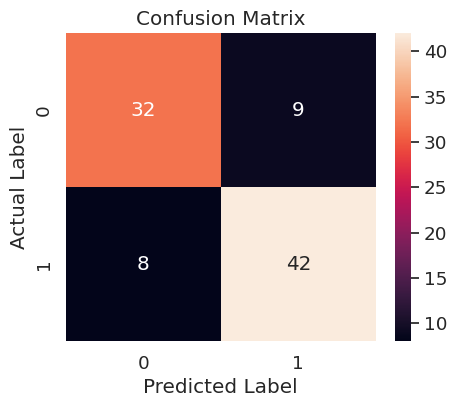

In [14]:

# ============================================================
# 13. 혼동행렬과 분류 리포트 확인
# ============================================================

# 혼동행렬은 실제값과 예측값이 어떻게 맞고 틀렸는지 보여줍니다.
# [[TN, FP],
#  [FN, TP]]
# TN: 실제 0을 0으로 맞힘
# FP: 실제 0을 1로 잘못 예측
# FN: 실제 1을 0으로 잘못 예측
# TP: 실제 1을 1로 맞힘
cm = confusion_matrix(Y_test_array, pred_class)

print("혼동행렬:")
print(cm)

# classification_report는 precision, recall, f1-score를 클래스별로 출력합니다.
print("\n분류 리포트:")
print(classification_report(Y_test_array, pred_class))

# 혼동행렬을 heatmap으로 시각화합니다.
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap=None)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()


,actual,pred_prob,pred_class
0,1,0.993564,1
1,1,0.599674,1
2,1,0.986664,1
3,0,0.036207,0
4,0,0.063500,0
5,0,0.357833,0
6,0,0.005651,0
7,0,0.324047,0
8,0,0.964780,1
9,1,0.964488,1


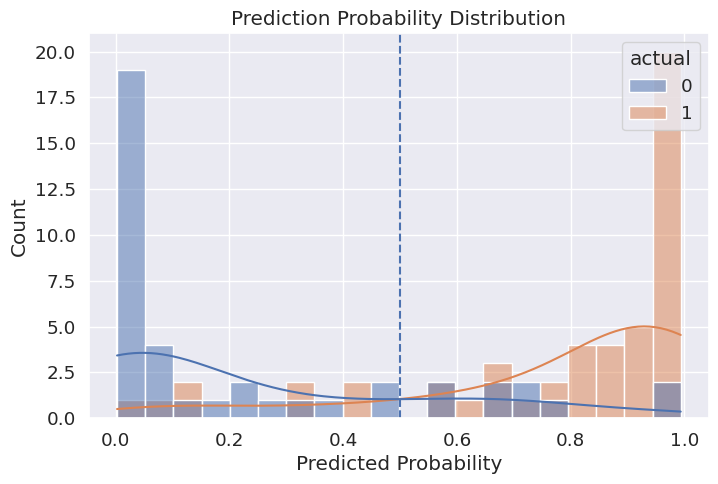

In [15]:

# ============================================================
# 14. 예측 확률 분포 시각화
# ============================================================

# 예측 확률을 데이터프레임으로 정리합니다.
result_df = pd.DataFrame({
    "actual": Y_test_array,
    "pred_prob": pred_prob.flatten(),
    "pred_class": pred_class
})

# 결과 일부를 확인합니다.
display(result_df.head(10))

# 예측 확률이 0과 1 사이에서 어떻게 분포하는지 확인합니다.
plt.figure(figsize=(8, 5))
sns.histplot(data=result_df, x="pred_prob", hue="actual", bins=20, kde=True)

# 0.5 기준선을 표시합니다.
# 이 선보다 오른쪽이면 1, 왼쪽이면 0으로 분류합니다.
plt.axvline(0.5, linestyle="--")

plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()



## 15. 정리

이 노트북에서는 `heart.csv` 데이터를 이용하여 PyTorch 기반 DNN 이진 분류 모델을 만들었습니다.

핵심 흐름은 다음과 같습니다.

1. CSV 데이터 읽기
2. 입력 데이터와 정답 데이터 분리
3. 학습용 / 평가용 데이터 분리
4. Z-점수 정규화
5. PyTorch 텐서 변환
6. DNN 모델 정의
7. 손실 함수와 최적화 함수 설정
8. 순전파, 손실 계산, 역전파, 가중치 갱신
9. 예측 확률을 0/1 클래스로 변환
10. Accuracy, F1 score, 혼동행렬로 모델 평가

추가 개선 방향으로는 `BCELoss`, `BCEWithLogitsLoss`, `Adam optimizer`, `Dropout`, `BatchNorm1d`, 학습/검증 손실 그래프 등을 적용할 수 있습니다.
